1. Import und Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

2. Daten einlesen

In [2]:
file_path = "../data/cleaned_wlags_Number_of_fires_by_month.csv"
# CSV mit Semikolon-Trenner einlesen
df_fires = pd.read_csv(file_path, sep=",", header=0, encoding="ISO-8859-1")
print(df_fires.columns)


Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')


In [3]:
file_path = "../data/cleaned_Alberta_monthly_mean.csv"
# CSV mit Semikolon-Trenner einlesen
df_weather = pd.read_csv(file_path, sep=",", header=0, encoding="ISO-8859-1")
print(df_fires.columns)

Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')





3. Datenbereinigung

In [4]:
# Monat numerisch machen
df_fires["Month"] = pd.to_datetime(df_fires["Month"], format="%B").dt.month

# Spalte time löschen
df_weather = df_weather.drop(columns=["time"])

#filter alberta
df_fires_alberta = df_fires[df_fires["Jurisdiction"] == "Alberta"].copy()
df_fires_alberta["Jurisdiction"].unique()

array(['Alberta'], dtype=object)

4. Merge data

In [5]:
print(df_fires_alberta.columns)
print(df_weather.columns)


Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')
Index(['temperature_2m_mean (Â°C)', 'temperature_2m_max (Â°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (Â°)', 'et0_fao_evapotranspiration (mm)',
       'Year', 'Month'],
      dtype='object')


In [6]:
df_merged = pd.merge(
    df_fires_alberta,
    df_weather,
    on=["Year", "Month"],
    how="inner"
)

In [7]:
print(df_merged.columns)
print(df_merged.dtypes)
df_merged.head(10)
print(df_merged.shape)
duplicates = df_merged.duplicated(subset=["Jurisdiction", "Year", "Month"]).sum()
print("Doppelte Schlüssel:", duplicates)
df_merged.isna().sum()

Index(['Jurisdiction', 'Month', 'Year', 'Number_fires',
       'temperature_2m_mean (Â°C)', 'temperature_2m_max (Â°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (Â°)', 'et0_fao_evapotranspiration (mm)'],
      dtype='object')
Jurisdiction                         object
Month                                 int32
Year                                  int64
Number_fires                        float64
temperature_2m_mean (Â°C)           float64
temperature_2m_max (Â°C)            float64
relative_humidity_2m_mean (%)       float64
relative_humidity_2m_min (%)        float64
precipitation_sum (mm)              float64
precipitation_hours (h)             float64
wind_speed_10m_mean (km/h)          float64
wind_speed_10m_max (km/h)           float64
wind_direction_10m_dominant (Â°)    float64
et0_fao_e

Jurisdiction                         0
Month                                0
Year                                 0
Number_fires                        12
temperature_2m_mean (Â°C)            0
temperature_2m_max (Â°C)             0
relative_humidity_2m_mean (%)        0
relative_humidity_2m_min (%)         0
precipitation_sum (mm)               0
precipitation_hours (h)              0
wind_speed_10m_mean (km/h)           0
wind_speed_10m_max (km/h)            0
wind_direction_10m_dominant (Â°)     0
et0_fao_evapotranspiration (mm)      0
dtype: int64

5. Korrelationsanalyse

In [8]:
corr_cols = [
    "Number_fires",
    "temperature_2m_mean (Â°C)",
    "temperature_2m_max (Â°C)",
    "relative_humidity_2m_mean (%)",
    "relative_humidity_2m_min (%)",
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "wind_speed_10m_mean (km/h)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (Â°)",
    "et0_fao_evapotranspiration (mm)"
]

df_corr = df_merged[corr_cols].dropna()


In [9]:
pearson_corr = df_corr.corr(method="pearson")
print(pearson_corr)


                                  Number_fires  temperature_2m_mean (Â°C)  \
Number_fires                          1.000000                   0.697809   
temperature_2m_mean (Â°C)             0.697809                   1.000000   
temperature_2m_max (Â°C)              0.708254                   0.997012   
relative_humidity_2m_mean (%)        -0.591214                  -0.436308   
relative_humidity_2m_min (%)         -0.660317                  -0.702803   
precipitation_sum (mm)                0.470844                   0.710024   
precipitation_hours (h)               0.198321                   0.384465   
wind_speed_10m_mean (km/h)           -0.171565                  -0.114492   
wind_speed_10m_max (km/h)             0.055148                   0.132154   
wind_direction_10m_dominant (Â°)     -0.156635                  -0.010428   
et0_fao_evapotranspiration (mm)       0.821595                   0.925189   

                                  temperature_2m_max (Â°C)  \
Number_fires 

In [10]:
spearman_corr = df_corr.corr(method="spearman")
print(spearman_corr)


                                  Number_fires  temperature_2m_mean (Â°C)  \
Number_fires                          1.000000                   0.861581   
temperature_2m_mean (Â°C)             0.861581                   1.000000   
temperature_2m_max (Â°C)              0.870677                   0.996645   
relative_humidity_2m_mean (%)        -0.661616                  -0.461885   
relative_humidity_2m_min (%)         -0.797478                  -0.663954   
precipitation_sum (mm)                0.625126                   0.747326   
precipitation_hours (h)               0.280320                   0.388715   
wind_speed_10m_mean (km/h)           -0.111575                  -0.142960   
wind_speed_10m_max (km/h)             0.132305                   0.092556   
wind_direction_10m_dominant (Â°)     -0.120808                   0.010089   
et0_fao_evapotranspiration (mm)       0.906652                   0.936210   

                                  temperature_2m_max (Â°C)  \
Number_fires 

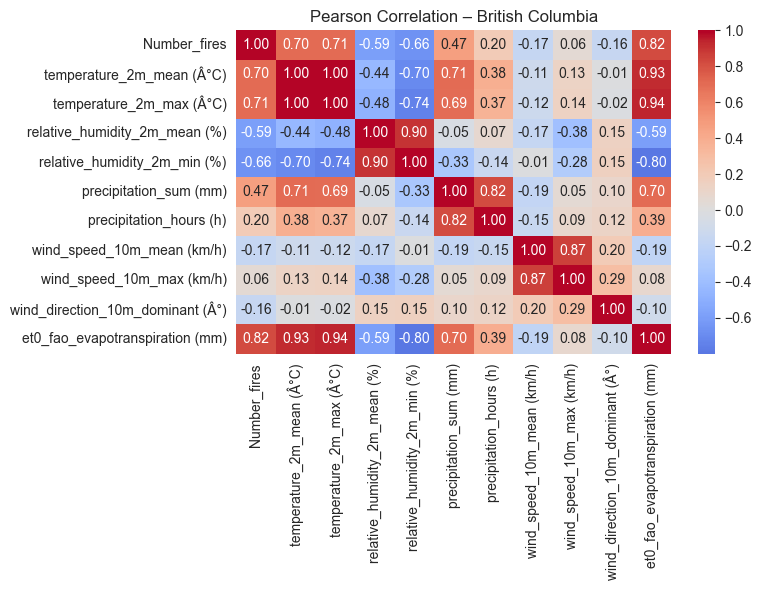

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation – British Columbia")
plt.tight_layout()
plt.show()


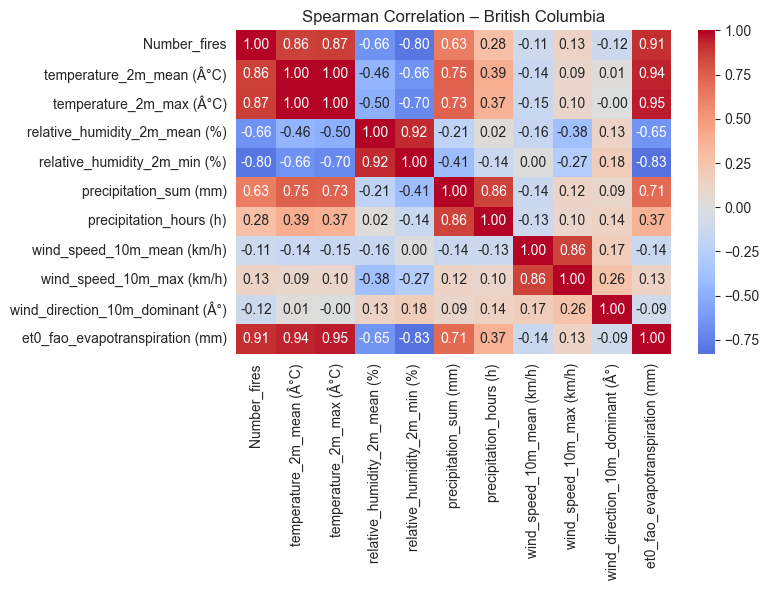

In [12]:
#Spearman heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation – British Columbia")
plt.tight_layout()
plt.show()

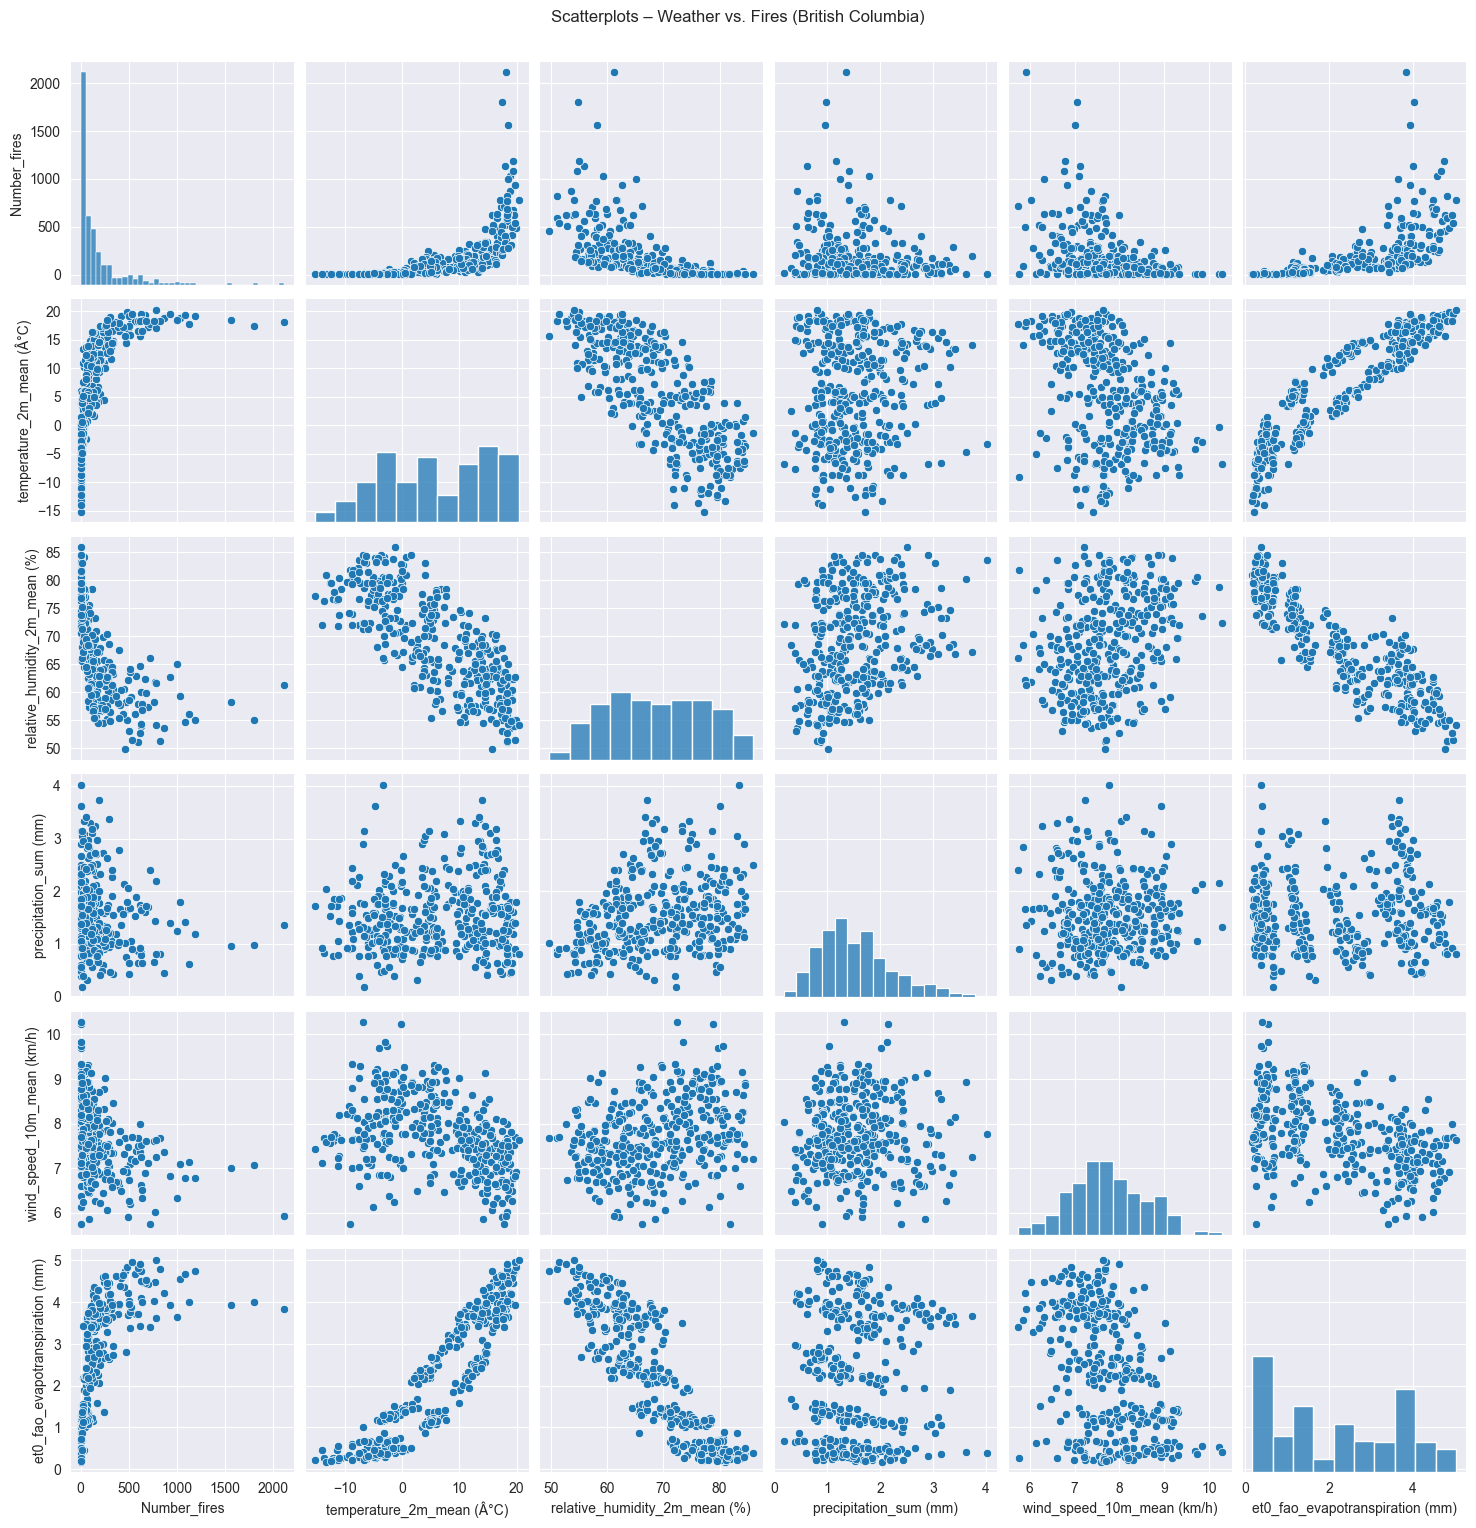

In [14]:
sns.pairplot(
    df_corr,
    kind="scatter",
    diag_kind="hist"
)
plt.suptitle("Scatterplots – Weather vs. Fires (British Columbia)", y=1.02)
plt.show()
